## 1. 당뇨병 수치를 맞춰보자!

In [84]:

# (1) 데이터 가져오기
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target


In [85]:

# (2) 모델에 입력할 데이터 X 준비하기
import numpy as np
X = np.array(df_X)
print(type(X), X.dtype)


<class 'numpy.ndarray'> float64


In [86]:

# (3) 모델에 예측할 데이터 y 준비하기
y = np.array(df_y)
print(type(y), y.dtype)


<class 'numpy.ndarray'> float64


In [87]:

#(4) train 데이터와 test 데이터로 분리하기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(353, 10) (353,)
(89, 10) (89,)


In [88]:

# (5) 모델  - W, b
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))


10


In [103]:

# (5) 모델 
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions


In [104]:

# (6) 손실함수 loss 정의하기  - MSE
def MSE(a, b):
    mse = ((a - b) ** 2).mean()  # 두 값의 차이의 제곱의 평균
    return mse
    

In [105]:

# (6) 손실함수 loss 정의하기
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L
    

In [107]:

# (7) 기울기를 구하는 gradient 함수 구현하기
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db
    

In [108]:

# (8) 하이퍼 파라미터인 학습률 설정하기
LEARNING_RATE = 0.2


In [112]:

%%timeit -n 1 -r 1  # (9) 모델 학습하기
global W, b

losses = []

for i in range(1, 1001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 100 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))


Iteration 100 : Loss 2899.6680
Iteration 200 : Loss 2899.4044
Iteration 300 : Loss 2899.1672
Iteration 400 : Loss 2898.9529
Iteration 500 : Loss 2898.7586
Iteration 600 : Loss 2898.5816
Iteration 700 : Loss 2898.4198
Iteration 800 : Loss 2898.2712
Iteration 900 : Loss 2898.1343
Iteration 1000 : Loss 2898.0075
176 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [113]:

# (10) test 데이터에 대한 성능 확인하기
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse


np.float64(2880.1773679988455)

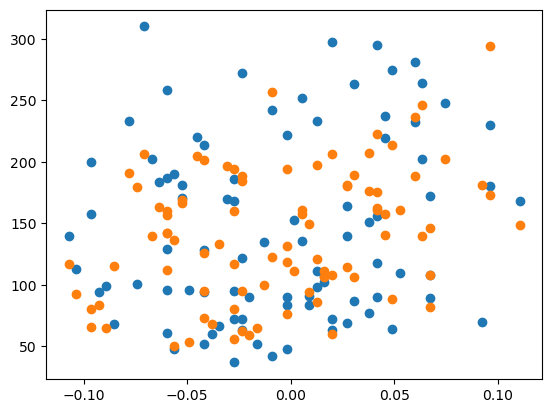

In [114]:

# (11) 정답 데이터와 예측한 데이터 시각화하기
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


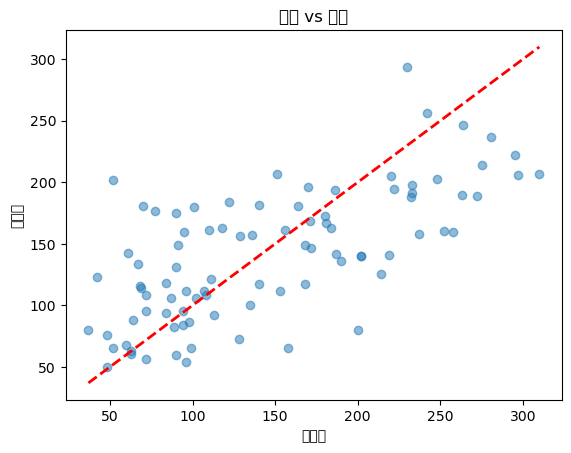

In [115]:
plt.scatter(y_test, prediction, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)  # 45도 대각선
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('실제 vs 예측')
plt.show()


- X축: 실제값, Y축: 예측값
- 점이 빨간 대각선에 가까울수록 예측이 정확
- "모델이 전체적으로 얼마나 잘 맞히나"
         → 성능 확인에 맞는 방식


## 당뇨병 수치 맞춰보기 (다른 모델 사용해보기)

<class 'numpy.ndarray'> float64
<class 'numpy.ndarray'> float64
(353, 10) (353,)
(89, 10) (89,)
2723.3244052715468
{'learning_rate': 0.04, 'max_depth': 2, 'n_estimators': 100}


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


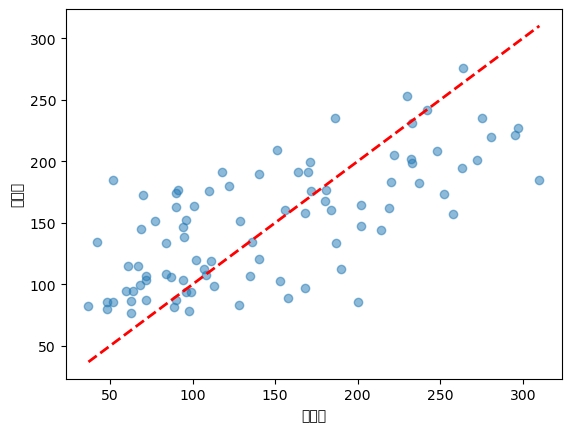

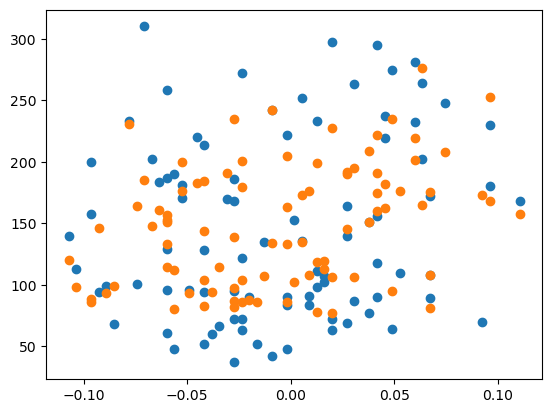

In [59]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

import numpy as np
X = np.array(df_X)
print(type(X), X.dtype)

y = np.array(df_y)
print(type(y), y.dtype)


# (4) train 데이터와 test 데이터로 분리하기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# (5) 모델 변경 1 Polynomial Features
# from sklearn.preprocessing import PolynomialFeatures, StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error

# pipe = Pipeline([
#     ('scaler', StandardScaler()),
#     ('poly', PolynomialFeatures(degree=2)),
#     ('lr', LinearRegression())
# ])

# pipe.fit(X_train, y_train)
# pred = pipe.predict(X_test)
# print("MSE : ",mean_squared_error(pred, y_test))

# # (5) 모델 변경 2 GradientBoostingRegressor
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.metrics import mean_squared_error

# gb = GradientBoostingRegressor(
#     n_estimators=200,      # 200 -> 500 -> 200
#     learning_rate=0.05,    # 0.05 -> 0.02 -> 0.05
#     max_depth=3,           # 트리 깊이 제한
#     random_state=42
# )
# gb.fit(X_train, y_train)
# pred = gb.predict(X_test)
# print(mean_squared_error(pred, y_test))

# # (5) 모델 변경 3 XGBoost 
# from xgboost import XGBRegressor
# from sklearn.metrics import mean_squared_error

# xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
# xgb.fit(X_train, y_train)
# pred = xgb.predict(X_test)
# print(mean_squared_error(pred, y_test))

# (5) 모델 변경 4 GridSearchCV  좀 느림.
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

params = {
    'n_estimators': [70, 100, 150],
    'learning_rate': [0.03, 0.04, 0.05],
    'max_depth': [2]
}
gs = GridSearchCV(GradientBoostingRegressor(random_state=42), 
                  params, cv=5, scoring='neg_mean_squared_error')
gs.fit(X_train, y_train)
pred = gs.best_estimator_.predict(X_test)
print(mean_squared_error(pred, y_test))   # 2723.3244052715468
print(gs.best_params_)   # 최적 파라메터

# # (5) 모델 변경 5 LinearRegression  
# from sklearn.linear_model import Ridge, Lasso, ElasticNet
# from sklearn.metrics import mean_squared_error

# ridge = Ridge(alpha=0.16)
# ridge.fit(X_train, y_train)
# pred_ridge = ridge.predict(X_test)
# print("Ridge:", mean_squared_error(pred_ridge, y_test)) # 2853.2925853762617

# lasso = Lasso(alpha=0.095)
# lasso.fit(X_train, y_train)
# pred_lasso = lasso.predict(X_test)
# print("Lasso:", mean_squared_error(pred_lasso, y_test))  # 2798.435744328816

# elastic = ElasticNet(alpha=0.00085)
# elastic.fit(X_train, y_train)
# pred_elastic = elastic.predict(X_test)
# print("ElasticNet:", mean_squared_error(pred_elastic, y_test))  # 2852.986102252925

# (6) 시각화
import matplotlib.pyplot as plt
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.show()


plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], pred)
plt.show()



## 프로젝트 2 : 날씨 좋은 월요일 오후 세 시, 자전거 타는 사람은 몇 명?


In [10]:

# (1) 데이터 가져오기
import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()
train

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [11]:

# (2) datetime 컬럼을 datetime 자료형으로 변환하고 연, 월, 일, 시, 분, 초까지 6가지 컬럼 생성하기

train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

# 추가
train['dayofweek'] = train['datetime'].dt.dayofweek
train['rush_hour'] = train['hour'].isin([7,8,9,17,18,19]).astype(int)

train['time_category'] = 0
train.loc[train['hour'].between(6, 9),   'time_category'] = 1
train.loc[train['hour'].between(11, 14), 'time_category'] = 2
train.loc[train['hour'].between(16, 20), 'time_category'] = 3
train.loc[train['hour'].between(21, 23), 'time_category'] = 4
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   datetime       10886 non-null  datetime64[ns]
 1   season         10886 non-null  int64         
 2   holiday        10886 non-null  int64         
 3   workingday     10886 non-null  int64         
 4   weather        10886 non-null  int64         
 5   temp           10886 non-null  float64       
 6   atemp          10886 non-null  float64       
 7   humidity       10886 non-null  int64         
 8   windspeed      10886 non-null  float64       
 9   casual         10886 non-null  int64         
 10  registered     10886 non-null  int64         
 11  count          10886 non-null  int64         
 12  year           10886 non-null  int32         
 13  month          10886 non-null  int32         
 14  day            10886 non-null  int32         
 15  hour           1088

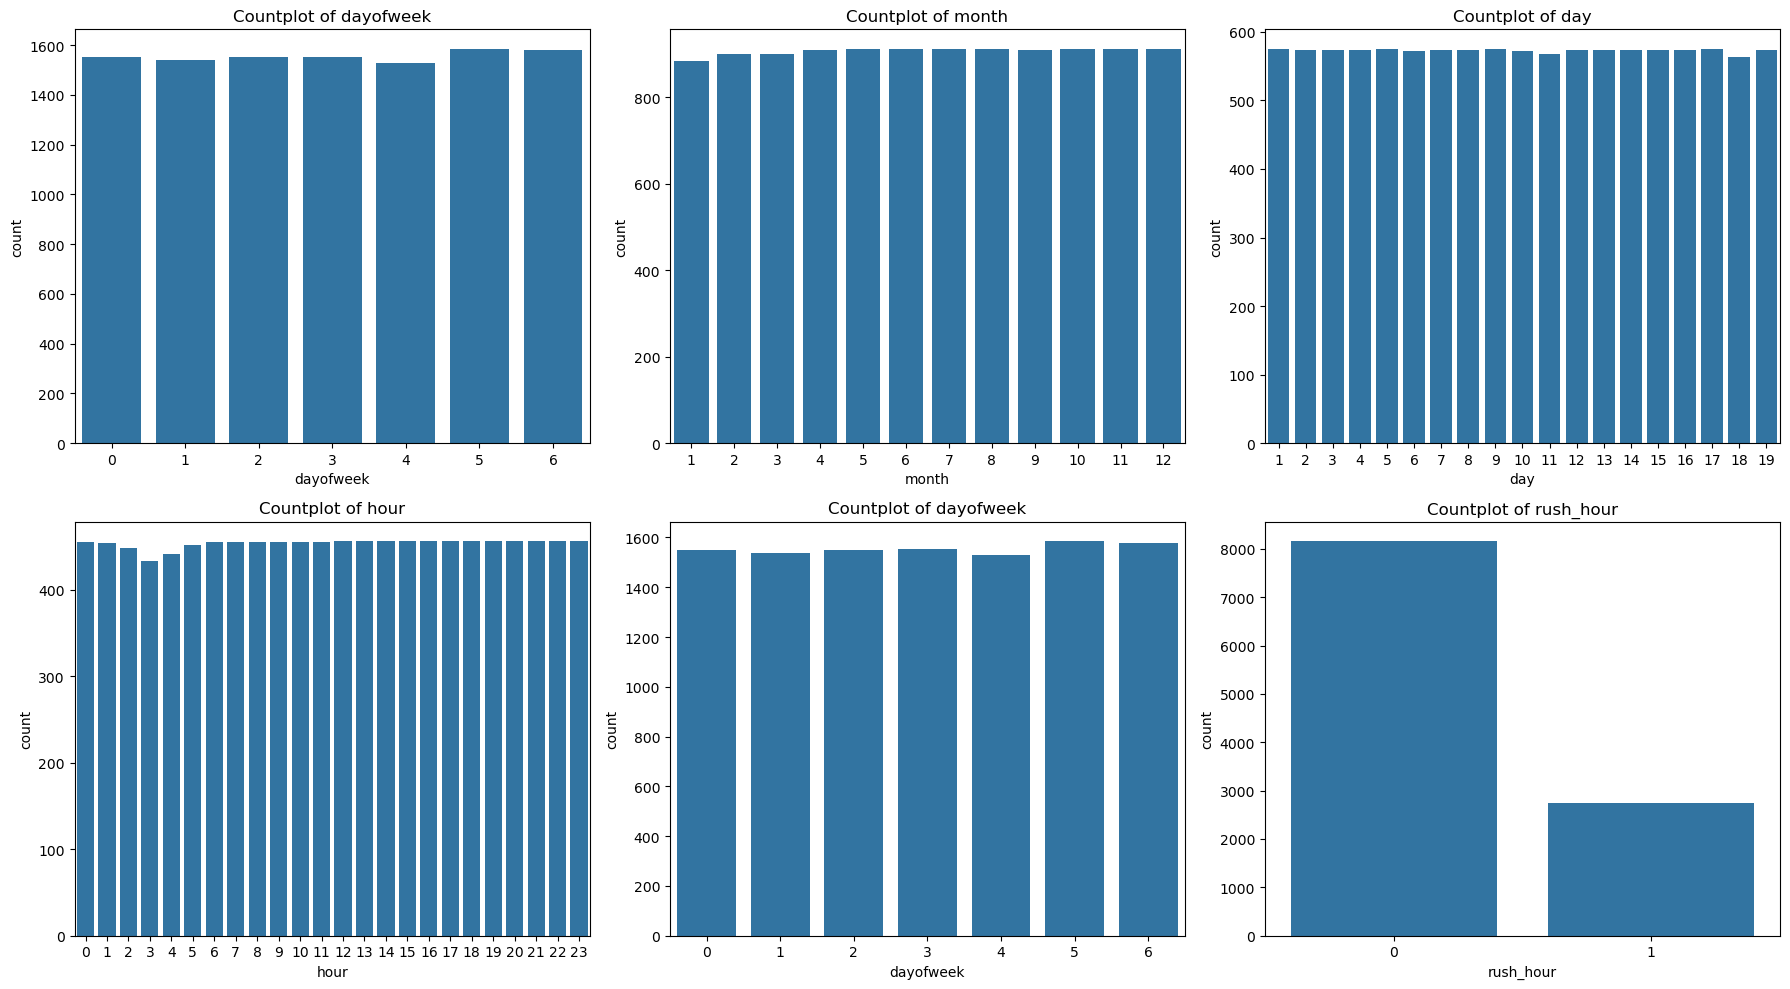

In [12]:

# (3) year, month, day, hour, minute, second 데이터 개수 시각화하기

import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['dayofweek', 'month', 'day', 'hour', 'dayofweek', 'rush_hour']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()


In [13]:

# (4) X, y 컬럼 선택 및 train/test 데이터 분리

#features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
features = ['hour', 'month', 'workingday', 'rush_hour','time_category', 'temp', 'humidity','dayofweek', 'weather', 'season']
X = train[features]
y = train['count']

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )


In [19]:

# (5) LinearRegression 모델 학습

# from sklearn.linear_model import LinearRegression

# model = LinearRegression()
# model.fit(X_train, y_train)

# # 모델변경 1 (RMSE: 127.00)
# from sklearn.ensemble import RandomForestRegressor

# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

# #  모델변경 2 (RMSE: 126.51)
# from sklearn.ensemble import GradientBoostingRegressor

# model = GradientBoostingRegressor(
#     n_estimators=200,
#     learning_rate=0.1,
#     max_depth=5,
#     random_state=42
# )
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

# # 모델변경 3  (RMSE: 126.51)
# from sklearn.ensemble import GradientBoostingRegressor

# model = GradientBoostingRegressor(
#     n_estimators=200,
#     learning_rate=0.1,
#     max_depth=5,
#     random_state=42
# )
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)

# 모델변경 4 (RMSE: 116.14)
# 데이터 분리하면서 모델학습
from xgboost import XGBRegressor
from sklearn.model_selection import KFold

model = XGBRegressor(
    n_estimators=500,    #200->300->500
    learning_rate=0.03,  #0.02 -> 0.03
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 학습
kf = KFold(n_splits=5, shuffle=False)
rmse_list = []
all_y_test = []
all_y_pred = []
all_X_test = []

# 5회 학습. 
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # 학습
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 각 회차별 rmse 저장
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list.append(rmse)

    # 각 회차별 테스트/예측값 저장
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)
    all_X_test.append(X_test)

all_X_test = pd.concat(all_X_test)
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)


In [29]:

# (6) 학습된 모델로 x_test에 대한 예측값 출력 및 손실함수값 계산

from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)
print("-"*50)

# 중요도
print("[Importance]")
importance = pd.Series(model.feature_importances_, index=features)
print(importance.sort_values(ascending=False))
print("-"*50)

# 각 회차별 RMSE 목록
print(f"[각 fold RMSE]\n{rmse_list}")
print("-"*50)

# 평균 RMSE
print(f"[평균 RMSE] {np.mean(rmse_list):.4f}")

MSE: 15072.7041015625
RMSE: 122.77094160086294
--------------------------------------------------
[Importance]
rush_hour        0.246009
hour             0.234611
workingday       0.162597
season           0.078288
temp             0.076583
time_category    0.059554
weather          0.040125
dayofweek        0.039597
humidity         0.033316
month            0.029320
dtype: float32
--------------------------------------------------
[각 fold RMSE]
[np.float64(116.57137198139601), np.float64(114.42004321386398), np.float64(101.41559567874657), np.float64(126.90419922622733), np.float64(122.77094160086294)]
--------------------------------------------------
[평균 RMSE] 116.4164


/tmp/ipykernel_128/3234845208.py:73: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_128/3234845208.py:73: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


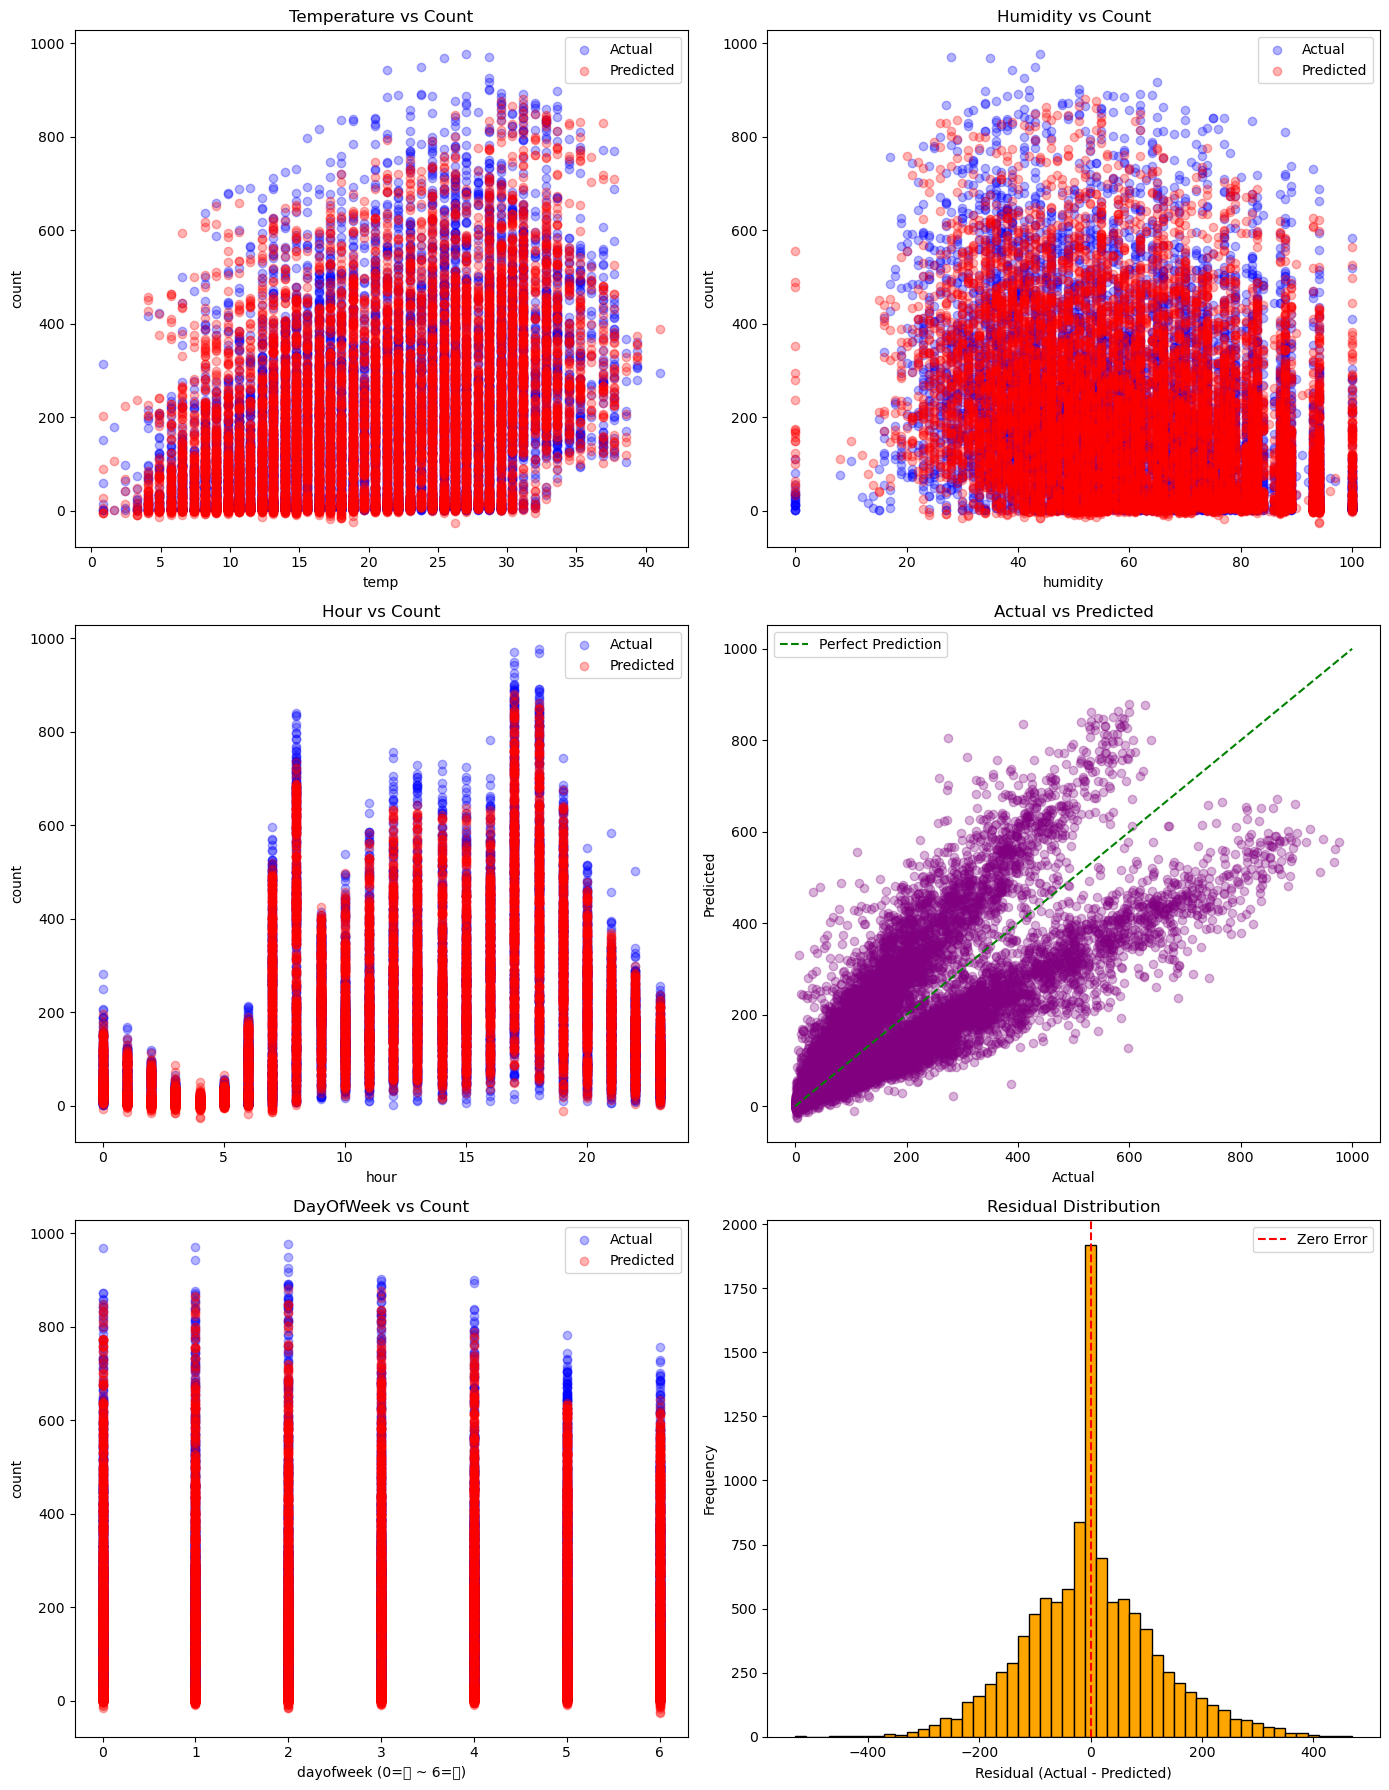

In [23]:

# (7) x축은 temp 또는 huminity로, y축은 count로 예측 결과 시각화하기

# fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# # temp vs count 시각화
# axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
# axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
# axs[0].set_xlabel('temp')
# axs[0].set_ylabel('count')
# axs[0].set_title('Temperature vs Count')
# axs[0].legend()

# # humidity vs count 시각화
# axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
# axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
# axs[1].set_xlabel('humidity')
# axs[1].set_ylabel('count')
# axs[1].set_title('Humidity vs Count')
# axs[1].legend()

# 그래프 항목 추가
fig, axs = plt.subplots(3, 2, figsize=(14, 18))

# 1. temp vs count
axs[0,0].scatter(all_X_test['temp'], all_y_test, color='blue', label='Actual', alpha=0.3)
axs[0,0].scatter(all_X_test['temp'], all_y_pred, color='red', label='Predicted', alpha=0.3)
axs[0,0].set_xlabel('temp')
axs[0,0].set_ylabel('count')
axs[0,0].set_title('Temperature vs Count')
axs[0,0].legend()

# 2. humidity vs count
axs[0,1].scatter(all_X_test['humidity'], all_y_test, color='blue', label='Actual', alpha=0.3)
axs[0,1].scatter(all_X_test['humidity'], all_y_pred, color='red', label='Predicted', alpha=0.3)
axs[0,1].set_xlabel('humidity')
axs[0,1].set_ylabel('count')
axs[0,1].set_title('Humidity vs Count')
axs[0,1].legend()

# 3. hour vs count
axs[1,0].scatter(all_X_test['hour'], all_y_test, color='blue', label='Actual', alpha=0.3)
axs[1,0].scatter(all_X_test['hour'], all_y_pred, color='red', label='Predicted', alpha=0.3)
axs[1,0].set_xlabel('hour')
axs[1,0].set_ylabel('count')
axs[1,0].set_title('Hour vs Count')
axs[1,0].legend()

# 4. 실제값 vs 예측값 직접 비교
axs[1,1].scatter(all_y_test, all_y_pred, color='purple', alpha=0.3)
axs[1,1].plot([0, 1000], [0, 1000], 'g--', label='Perfect Prediction')
axs[1,1].set_xlabel('Actual')
axs[1,1].set_ylabel('Predicted')
axs[1,1].set_title('Actual vs Predicted')
axs[1,1].legend()

# 5. 요일별
axs[2,0].scatter(all_X_test['dayofweek'], all_y_test, color='blue', label='Actual', alpha=0.3)
axs[2,0].scatter(all_X_test['dayofweek'], all_y_pred, color='red', label='Predicted', alpha=0.3)
axs[2,0].set_xlabel('dayofweek (0=월 ~ 6=일)')
axs[2,0].set_ylabel('count')
axs[2,0].set_title('DayOfWeek vs Count')
axs[2,0].legend()

# 6. 잔차(실제값 - 예측값) 분포
residuals = np.array(all_y_test) - np.array(all_y_pred)
axs[2,1].hist(residuals, bins=50, color='orange', edgecolor='black')
axs[2,1].axvline(x=0, color='red', linestyle='--', label='Zero Error')
axs[2,1].set_xlabel('Residual (Actual - Predicted)')
axs[2,1].set_ylabel('Frequency')
axs[2,1].set_title('Residual Distribution')
axs[2,1].legend()

plt.tight_layout()
plt.show()


## 그래프 분석
1. Temperature vs Count
    - 온도(x축) 에 따라 실제/예측 count 비교
    - 온도 높을수록 대여 많아지는 패턴을 잡는지 확인
2. Humidity vs Count
    - 습도(x축) 에 따라 실제/예측 count 비교
    - 고습도일수록 대여 줄어드는 패턴을 잡는지 확인
3. Hour vs Count
   - 시간대(x축) 에 따라 실제/예측 count 비교
    - 출퇴근 피크(8시, 18시) 패턴을 잡는지 확인
    - 가장 중요한 그래프 (hour가 importance 1위)
4. Actual vs Predicted
    - x축 = 실제값, y축 = 예측값
    - 점이 녹색 대각선에 가까울수록 → 좋은 예측
    - 점이 대각선 아래 → 과소예측
    - 점이 대각선 위  → 과대예측
    - 조건 상관없이 "전체적으로" 얼마나 잘 맞는지 모델 성능을 한눈에 확인.
        - 0~400 구간   → 대각선에 딱 붙어있음 ok → 낮은 수요 잘 맞춤
        - 600~1000 구간 → 대각선 아래로 처짐  x  → 높은 수요 과소예측
5. DayOfWeek vs Count
    - 요일(x축 0=월 ~ 6=일) 에 따라 실제/예측 비교
    - 평일/주말 패턴을 잡는지 확인
7. Residual Distribution
    - 잔차(실제-예측) 의 분포
    - 0 중심 (좌우 대칭 종모양 - 정규분포) → 좋은 모델
    - 오른쪽 치우침 → 과소예측 많음
    - 왼쪽 치우침  → 과대예측 많음
    - 과소/과대 예측이 균형잡혀 있음.

## 공통 패턴
```
파랑(Actual)  = all_y_test = 원본 데이터 실제값
빨강(Predicted) = all_y_pred = 모델이 예측한 값

파랑과 빨강이 겹칠수록 → 좋은 모델

"피크 시간대 대여량을 낮게 예측한다"